<a href="https://colab.research.google.com/github/Korchomnyi-Ivan/Korchomnyi-Ivan-Machine-3-15/blob/main/%D0%9B%D0%A0_9_1_%D0%9A%D0%BE%D1%80%D1%87%D0%BE%D0%BC%D0%BD%D0%BE%D0%B3%D0%BE_%D0%86_%D0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Був присутній на парі

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Leukemia_GSE9476.csv to Leukemia_GSE9476 (2).csv


In [ ]:
df = pd.read_csv('Leukemia_GSE9476.csv')

df

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,1,Bone_Marrow_CD34,7.745245,7.811210,6.477916,8.841506,4.546941,7.957714,5.344999,4.673364,...,5.058849,6.810004,12.800060,12.718612,5.391512,4.666166,3.974759,3.656693,4.160622,4.139249
1,12,Bone_Marrow_CD34,8.087252,7.240673,8.584648,8.983571,4.548934,8.011652,5.579647,4.828184,...,4.436153,6.751471,12.472706,12.333593,5.379738,4.656786,4.188348,3.792535,4.204414,4.122700
2,13,Bone_Marrow_CD34,7.792056,7.549368,11.053504,8.909703,4.549328,8.237099,5.406489,4.615572,...,4.392061,6.086295,12.637384,12.499038,5.316604,4.600566,3.845561,3.635715,4.174199,4.067152
3,14,Bone_Marrow_CD34,7.767265,7.094460,11.816433,8.994654,4.697018,8.283412,5.582195,4.903684,...,4.633334,6.375991,12.903630,12.871454,5.179951,4.641952,3.991634,3.704587,4.149938,3.910150
4,15,Bone_Marrow_CD34,8.010117,7.405281,6.656049,9.050682,4.514986,8.377046,5.493713,4.860754,...,5.305192,6.700453,12.949352,12.782515,5.341689,4.560315,3.887020,3.629853,4.127513,4.004316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,PBSC_CD34,7.686106,6.856961,6.822222,8.849700,4.440703,8.456949,5.408897,4.708615,...,4.969400,7.016576,12.997293,12.828832,5.084120,4.531087,3.884230,3.619301,4.108490,4.070028
60,61,PBSC_CD34,7.816168,6.875124,6.532324,8.827857,4.515457,8.450286,5.482797,4.667874,...,4.826255,6.577223,12.990305,12.855352,5.260451,4.568651,3.927693,3.634879,4.112277,4.064780
61,62,PBSC_CD34,7.863092,6.896242,6.630690,8.775139,4.458048,8.664517,5.577298,4.853996,...,5.065816,6.583261,12.786121,12.588852,5.451940,4.739944,4.010427,3.668713,4.162220,4.102264
62,63,PBSC_CD34,7.900992,6.787515,6.642927,8.856187,4.499548,9.188459,5.471110,4.637444,...,4.985061,6.815527,13.020089,12.824868,5.459571,4.602105,4.019624,3.570563,4.141371,4.102641


In [ ]:
df.info

<bound method DataFrame.info of     samples              type  1007_s_at   1053_at     117_at    121_at  \
0         1  Bone_Marrow_CD34   7.745245  7.811210   6.477916  8.841506   
1        12  Bone_Marrow_CD34   8.087252  7.240673   8.584648  8.983571   
2        13  Bone_Marrow_CD34   7.792056  7.549368  11.053504  8.909703   
3        14  Bone_Marrow_CD34   7.767265  7.094460  11.816433  8.994654   
4        15  Bone_Marrow_CD34   8.010117  7.405281   6.656049  9.050682   
..      ...               ...        ...       ...        ...       ...   
59       60         PBSC_CD34   7.686106  6.856961   6.822222  8.849700   
60       61         PBSC_CD34   7.816168  6.875124   6.532324  8.827857   
61       62         PBSC_CD34   7.863092  6.896242   6.630690  8.775139   
62       63         PBSC_CD34   7.900992  6.787515   6.642927  8.856187   
63       64         PBSC_CD34   8.004488  6.657433   6.705597  8.778333   

    1255_g_at   1294_at   1316_at   1320_at  ...  AFFX-r2-Hs28SrRNA-5_at  \
0    4.546941  7.957714  5.344999  4.673364  ...                5.058849   
1    4.548934  8.011652  5.579647  4.828184  ...                4.436153   
2    4.549328  8.237099  5.406489  4.615572  ...                4.392061   
3    4.697018  8.283412  5.582195  4.903684  ...                4.633334   
4    4.514986  8.377046  5.493713  4.860754  ...                5.305192   
..        ...       ...       ...       ...  ...                     ...   
59   4.440703  8.456949  5.408897  4.708615  ...                4.969400   
60   4.515457  8.450286  5.482797  4.667874  ...                4.826255   
61   4.458048  8.664517  5.577298  4.853996  ...                5.065816   
62   4.499548  9.188459  5.471110  4.637444  ...                4.985061   
63   4.599833  8.701859  5.481296  4.640955  ...                4.707060   

    AFFX-r2-Hs28SrRNA-M_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0                 6.810004            12.800060            12.718612   
1                 6.751471            12.472706            12.333593   
2                 6.086295            12.637384            12.499038   
3                 6.375991            12.903630            12.871454   
4                 6.700453            12.949352            12.782515   
..                     ...                  ...                  ...   
59                7.016576            12.997293            12.828832   
60                6.577223            12.990305            12.855352   
61                6.583261            12.786121            12.588852   
62                6.815527            13.020089            12.824868   
63                6.454188            12.994600            12.845402   

    AFFX-ThrX-3_at  AFFX-ThrX-5_at  AFFX-ThrX-M_at  AFFX-TrpnX-3_at  \
0         5.391512        4.666166        3.974759         3.656693   
1         5.379738        4.656786        4.188348         3.792535   
2         5.316604        4.600566        3.845561         3.635715   
3         5.179951        4.641952        3.991634         3.704587   
4         5.341689        4.560315        3.887020         3.629853   
..             ...             ...             ...              ...   
59        5.084120        4.531087        3.884230         3.619301   
60        5.260451        4.568651        3.927693         3.634879   
61        5.451940        4.739944        4.010427         3.668713   
62        5.459571        4.602105        4.019624         3.570563   
63        5.371230        4.618882        3.978051         3.638367   

    AFFX-TrpnX-5_at  AFFX-TrpnX-M_at  
0          4.160622         4.139249  
1          4.204414         4.122700  
2          4.174199         4.067152  
3          4.149938         3.910150  
4          4.127513         4.004316  
..              ...              ...  
59         4.108490         4.070028  
60         4.112277         4.064780  
61         4.162220         4.102264  
62         4.141371         4.102641  
63     

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target = df["type"]
target.value_counts()

,count
type,
AML,26
PB,10
Bone_Marrow,10
PBSC_CD34,10
Bone_Marrow_CD34,8


In [ ]:
# Визначимо target і числові ознаки

data = df.drop(columns=["samples", "type"])  # залишаємо лише гени

# Обчислення z-score
z_scores = data.apply(zscore).abs()

outliers_mask = z_scores > 3

# Частка ознак-викидів у рядку
outlier_fraction = outliers_mask.mean(axis=1)

# Індекси рядків, де більше 20% ознак — викиди
outlier_indices = outlier_fraction[outlier_fraction > 0.2].index

# Видаляємо викиди
df = df.drop(index=outlier_indices)
target = target.drop(index=outlier_indices)

In [ ]:
df.shape

(64, 22285)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
  data,
  target,
  test_size=0.2,
  random_state=42
)

In [ ]:
scaler = StandardScaler().set_output(transform='pandas')

X_train = scaler. fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
pca = PCA().set_output(transform='pandas').fit(X_train)

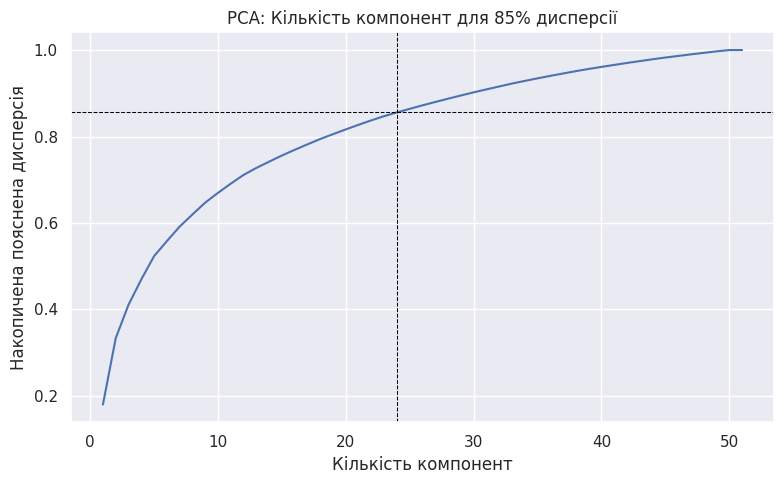

In [ ]:
# Кумулятивна сума поясненої дисперсії
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Створення графіка
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(x=np.arange(1, len(explained_variance) + 1), y=explained_variance, ax=ax)

ax.set(
    xlabel='Кількість компонент',
    ylabel='Накопичена пояснена дисперсія',
    title='PCA: Кількість компонент для 85% дисперсії'
)

# Знаходимо кількість компонент, достатню для 85%
n_components = np.searchsorted(explained_variance, 0.85) + 1  # +1 бо індексація з 0

# Вертикальна і горизонтальна лінії
ax.axvline(x=n_components, color='black', linestyle='--', linewidth=0.75)
ax.axhline(y=explained_variance[n_components - 1], color='black', linestyle='--', linewidth=0.75)

plt.tight_layout()
plt.show()

In [ ]:
X_train_pca = pca. transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
X_train_pca.iloc[:, :n_components].head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23
13,16.820999,34.903574,-0.890093,11.339648,41.858329,-43.650248,19.498081,-38.811836,3.569116,-3.708797,...,-4.926885,-4.775903,-9.667523,-1.280651,12.311428,1.945766,-2.897287,-12.958723,-8.618061,4.344385
34,44.894760,-12.157780,-57.720991,53.716727,-62.184216,-22.503680,17.746703,3.415854,19.813474,21.489266,...,79.838325,-3.788930,15.092687,-29.132727,17.134900,-4.434168,-14.445294,-0.041625,-10.276779,0.389676
50,-24.682635,131.334127,9.749087,-3.021057,-19.243698,-6.702661,0.440195,29.895475,4.879099,4.985307,...,0.839195,8.904300,-4.982312,3.954331,7.133173,4.702663,-6.966067,23.984453,-4.821261,-2.230078
3,40.891589,-64.783435,-16.635704,-27.814461,41.382949,-5.982859,-8.663965,39.164372,-1.307748,20.488950,...,-8.783102,-2.645770,-6.764236,4.933173,44.976101,-11.261858,11.582371,-10.032525,7.644777,6.329901
17,15.649074,37.946291,15.427679,18.151486,43.914519,-32.950138,-0.674742,-22.158600,5.028498,-30.223438,...,0.487636,-7.279847,-1.405508,-3.530243,-5.739945,-0.903455,2.138695,5.399026,-3.720250,-5.876050


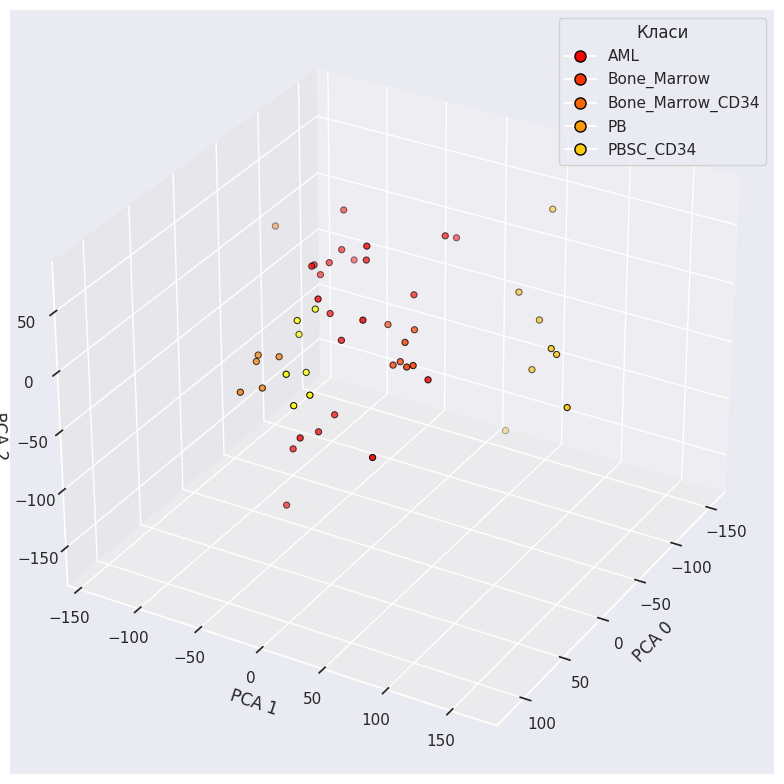

In [ ]:
#Перетворимо PCA-результати у DataFrame
pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f"pca{i}" for i in range(X_train_pca.shape[1])],
    index=y_train.index  # індекс важливо зберегти
)

# Закодуємо текстові мітки класів у числа
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Побудуємо 3D-графік
plt.figure(figsize=(8, 8))
ax = plt.subplot(projection='3d')

scatter = ax.scatter3D(
    pca_df["pca0"],
    pca_df["pca1"],
    pca_df["pca2"],
    c=y_train_encoded,
    cmap='autumn',
    s=20,
    edgecolor='black',
    linewidth=0.75
)

# Оформлення графіка
ax.set_xlabel("PCA 0")
ax.set_ylabel("PCA 1")
ax.set_zlabel("PCA 2")
ax.view_init(elev=30, azim=30)

# Кольори для кожного класу
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=plt.cm.autumn(i / len(label_encoder.classes_)),
           markeredgecolor='black', markersize=8)
    for i, label in enumerate(label_encoder.classes_)
]
ax.legend(handles=legend_elements, title="Класи", loc='best')

# 6. Показуємо
plt.tight_layout()
plt.show()

In [ ]:
clf_full = GradientBoostingClassifier()

clf_full.fit(X_train, y_train)

pred_full = clf_full.predict(X_test)

score_full = accuracy_score(y_test, pred_full)

print(f'Model accuracy: {score_full:.1%}')

Model accuracy: 92.3%


In [ ]:
clf_pca = GradientBoostingClassifier()

clf_pca.fit(X_train_pca.iloc[:, :n_components], y_train)

pred_pca = clf_pca.predict(X_test_pca.iloc[:, :n_components])

score_pca = accuracy_score(y_test, pred_pca)

print(f'Model accuracy (PCA): {score_pca:.1%}')

Model accuracy (PCA): 69.2%


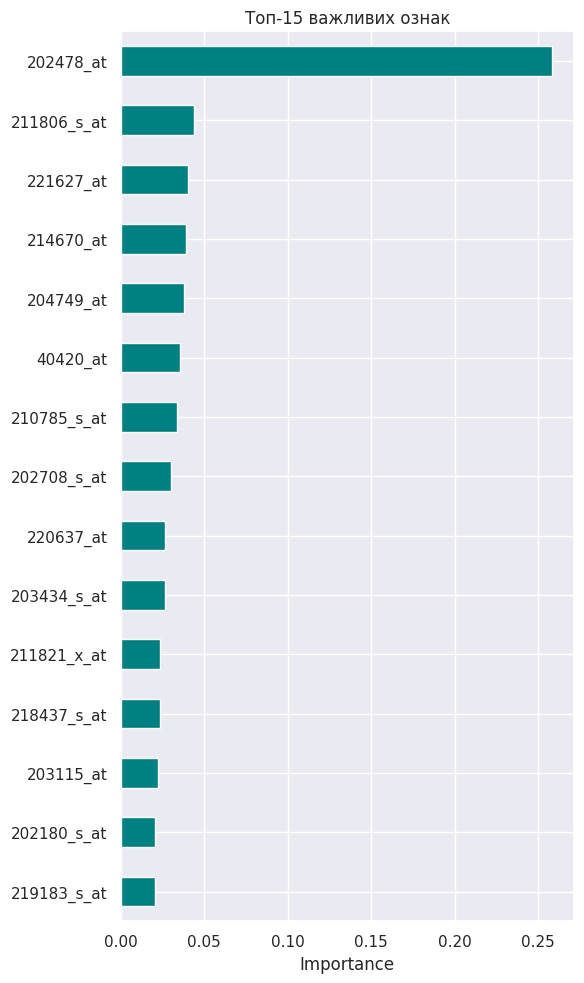

In [ ]:
# Отримуємо важливість та обираємо топ-30 ознак
importances = pd.Series(
    data=clf_full.feature_importances_,
    index=X_train.columns
)

top_features = importances.sort_values(ascending=False).head(15)

# Побудова горизонтального barplot
plt.figure(figsize=(6, 10))
top_features.sort_values().plot.barh(color='teal')
plt.title("Топ-15 важливих ознак")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

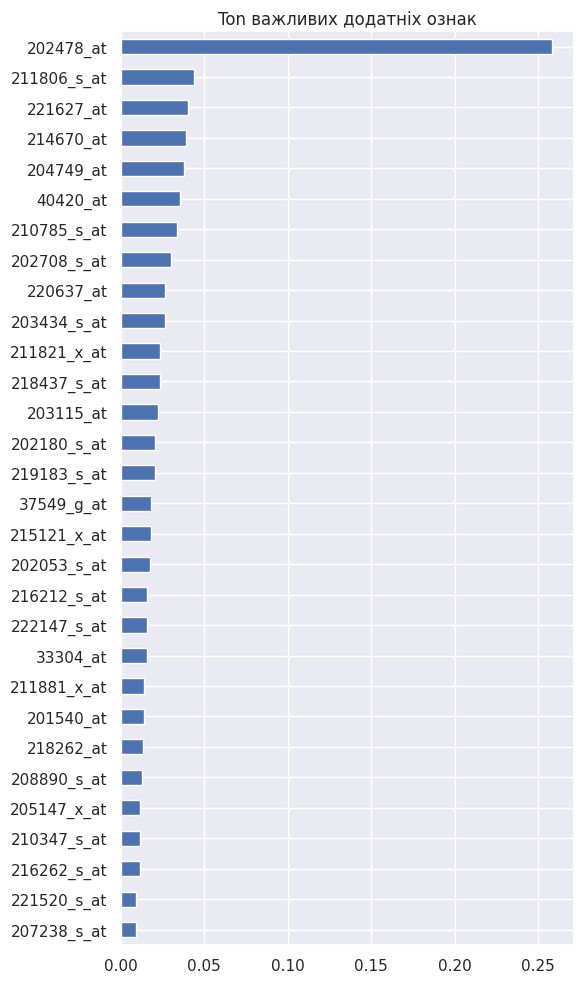

In [ ]:
nonzero = importances[importances > 0]
top = nonzero.sort_values(ascending=False).head(30)

plt.figure(figsize=(6, 10))
top.sort_values().plot.barh()
plt.title("Ton важливих додатніх ознак")
plt.tight_layout ()
plt.show()

Висновок: В ході роботи був побудований класифікатор на повному дата сеті та на PCA. Точність впала так як із 22285 залишисося всього 24. Виведено топ 15 важливих ознак ознак.